In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.0_acc0.0_test.csv" 
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.02_acc0.025_test.csv" 

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ==========================================
# 2. LOAD DATA
# ==========================================
if not os.path.exists(CSV_PATH):
    print(f"❌ Error: File not found at {CSV_PATH}")
    print("Please check the path and try again.")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Successfully loaded data!")
    print(f"   Rows (Envs): {df.shape[0]}")
    print(f"   Columns:     {df.shape[1]}")
    print(f"Columns found: {list(df.columns)[:10]} ... and {len(df.columns)-10} more")

    # Display the dataframe
    # display(df)

✅ Successfully loaded data!
   Rows (Envs): 16384
   Columns:     4849
Columns found: ['env_id', 'seed', 'range_type', 'start_t', 'end_t', 'gt_mass', 'gt_mu', 'gt_fric_force', 'cube_size', 'raw_ee_acc_t0_ax0'] ... and 4839 more


In [21]:
# --- FIX DATA TYPES ---
# The 'gt_fric_force' column was saved as strings (e.g., "[4.23]"). 
# We need to strip brackets and convert to float.
def clean_force_col(x):
    if isinstance(x, str):
        # Remove '[' and ']' and convert to float
        return float(x.strip('[]'))
    return x

if 'gt_fric_force' in df.columns:
    df['gt_fric_force'] = df['gt_fric_force'].apply(clean_force_col)
    print("✅ Fixed 'gt_fric_force' column types.")

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def get_sequence_data(row, prefix, seq_len=100, num_axes=6):
    """Reconstructs (100, 6) array from flattened columns like 'prefix_t0_ax0'"""
    data = np.zeros((seq_len, num_axes))
    for t in range(seq_len):
        for ax in range(num_axes):
            col = f"{prefix}_t{t}_ax{ax}"
            if col in row:
                data[t, ax] = row[col]
    return data

def get_flat_window(row, prefix, window_size=10):
    """Reconstructs 1D array from columns like 'prefix_0', 'prefix_1'"""
    data = np.zeros(window_size)
    for i in range(window_size):
        col = f"{prefix}_{i}"
        if col in row:
            data[i] = row[col]
    return data

✅ Fixed 'gt_fric_force' column types.



ANALYZING SAMPLE #6375
GT Mass: 0.170 kg
GT Mu:   0.544
GT Fric Force (Target): 1.066 N
Time Window: 62 -> 82


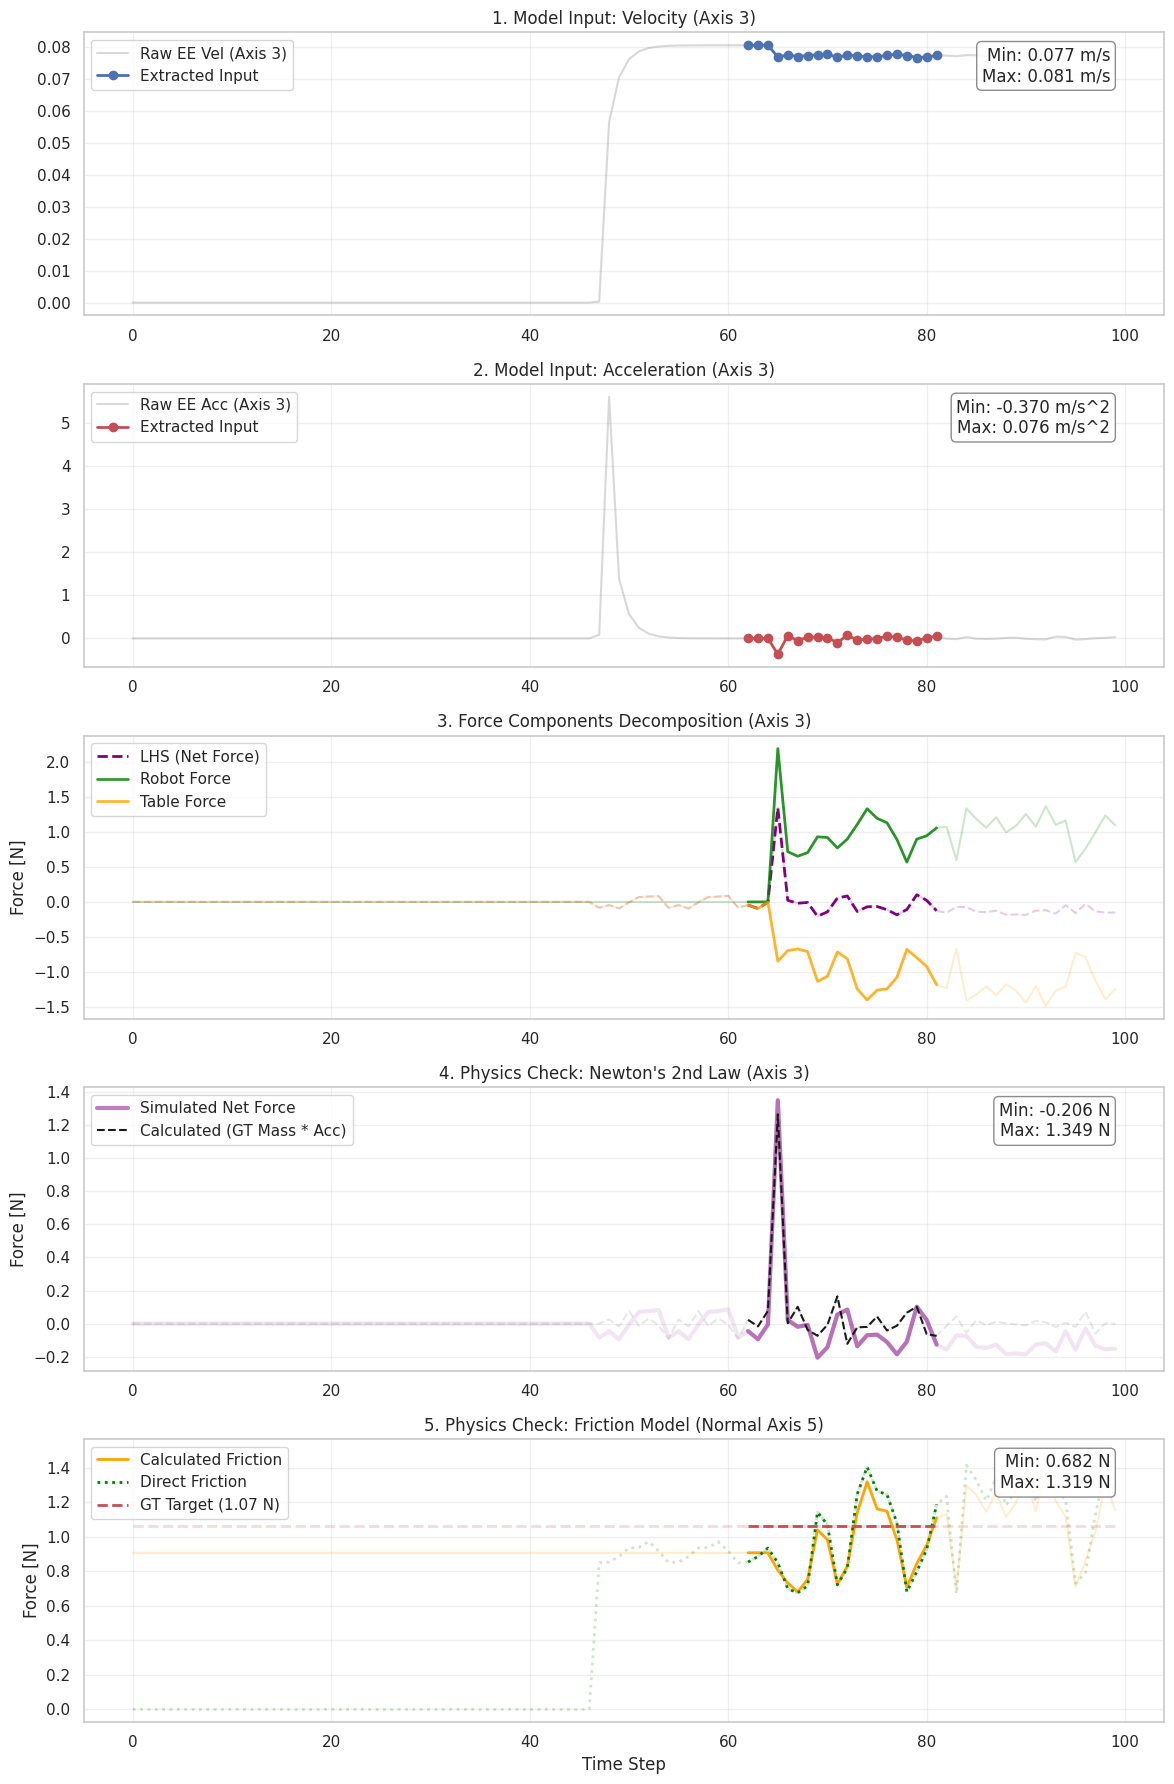

In [22]:
# ==========================================
# 5. INTEGRATED SAMPLE ANALYSIS (UPDATED WITH HIGHLIGHTS + MIN/MAX)
# ==========================================
if 'df' in locals():
    # --- CONFIGURATION ---
    AXIS_MOTION = 3   
    AXIS_VERTICAL = 5 
    G = 9.81

    # 1. Pick a single random sample for ALL plots
    sample_idx = np.random.randint(0, len(df))
    row = df.iloc[sample_idx]
    
    print(f"\n=======================================================")
    print(f"ANALYZING SAMPLE #{sample_idx}")
    print(f"=======================================================")
    print(f"GT Mass: {row['gt_mass']:.3f} kg")
    print(f"GT Mu:   {row['gt_mu']:.3f}")
    
    gt_fric_force_val = row['gt_fric_force']
    if isinstance(gt_fric_force_val, str):
        gt_fric_force_val = float(gt_fric_force_val.strip('[]'))
    print(f"GT Fric Force (Target): {gt_fric_force_val:.3f} N")
    print(f"Time Window: {int(row['start_t'])} -> {int(row['end_t'])}")

    # --- HELPER TO ADD MIN/MAX TEXT ---
    def add_min_max_text(ax, data, unit=""):
        dmin, dmax = np.min(data), np.max(data)
        stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # --- 2. EXTRACT DATA ---
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    lhs_wrench = get_sequence_data(row, "pinn_LHS_wrench")      
    rhs_acc = get_sequence_data(row, "pinn_RHS_acc")            
    robot_wrench = get_sequence_data(row, "pinn_robot_wrench")  
    table_wrench = get_sequence_data(row, "pinn_table_wrench")  
    
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)

    # --- 3. CALCULATIONS ---
    # Newton Check
    net_force_sim = lhs_wrench[:, AXIS_MOTION]
    acc_sim = rhs_acc[:, AXIS_MOTION]
    net_force_calc = row['gt_mass'] * acc_sim

    # Friction Check
    robot_force_vertical = robot_wrench[:, AXIS_VERTICAL]
    normal_force_calc = (row['gt_mass'] * G) - robot_force_vertical
    fric_force_calc_profile = row['gt_mu'] * normal_force_calc
    
    normal_force_direct = table_wrench[:, AXIS_VERTICAL]
    fric_force_direct_profile = row['gt_mu'] * normal_force_direct
    
    fric_force_gt_line = np.full_like(fric_force_calc_profile, gt_fric_force_val)

    # --- 4. PLOTTING ---
    fig, axes = plt.subplots(5, 1, figsize=(12, 18))
    
    # Plot 1: Velocity Input
    axes[0].plot(raw_vel[:, AXIS_MOTION], label=f'Raw EE Vel (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[0].plot(time_steps, input_vel, 'b-o', linewidth=2, label='Extracted Input')
    
    axes[0].set_title(f"1. Model Input: Velocity (Axis {AXIS_MOTION})")
    add_min_max_text(axes[0], input_vel, "m/s") # Add stats
    axes[0].legend(loc='upper left')

    # Plot 2: Acceleration Input
    axes[1].plot(raw_acc[:, AXIS_MOTION], label=f'Raw EE Acc (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[1].plot(time_steps, input_acc, 'r-o', linewidth=2, label='Extracted Input')
    
    axes[1].set_title(f"2. Model Input: Acceleration (Axis {AXIS_MOTION})")
    add_min_max_text(axes[1], input_acc, "m/s^2") # Add stats
    axes[1].legend(loc='upper left')

    # Plot 3: Component Breakdown
    lhs_val = lhs_wrench[:, AXIS_MOTION]
    robot_val = robot_wrench[:, AXIS_MOTION]
    table_val = table_wrench[:, AXIS_MOTION]
    
    # Background
    axes[2].plot(lhs_val, color='purple', linestyle='--', alpha=0.2)
    axes[2].plot(robot_val, color='green', alpha=0.2)
    axes[2].plot(table_val, color='orange', alpha=0.2)
    
    # Foreground
    net_win = lhs_val[time_steps]
    axes[2].plot(time_steps, net_win, label='LHS (Net Force)', color='purple', linestyle='--', linewidth=2)
    axes[2].plot(time_steps, robot_val[time_steps], label='Robot Force', color='green', alpha=0.8, linewidth=2)
    axes[2].plot(time_steps, table_val[time_steps], label='Table Force', color='orange', alpha=0.8, linewidth=2)
    
    axes[2].set_title(f"3. Force Components Decomposition (Axis {AXIS_MOTION})")
    axes[2].set_ylabel("Force [N]")
    axes[2].legend(loc='upper left')

    # Plot 4: Newton's Law Check
    # Background
    axes[3].plot(net_force_sim, color='purple', linewidth=3, alpha=0.1)
    axes[3].plot(net_force_calc, 'k--', linewidth=1.5, alpha=0.1)
    
    # Foreground
    sim_win = net_force_sim[time_steps]
    axes[3].plot(time_steps, sim_win, label='Simulated Net Force', color='purple', linewidth=3, alpha=0.5)
    axes[3].plot(time_steps, net_force_calc[time_steps], 'k--', label='Calculated (GT Mass * Acc)', linewidth=1.5)
    
    axes[3].set_title(f"4. Physics Check: Newton's 2nd Law (Axis {AXIS_MOTION})")
    axes[3].set_ylabel("Force [N]")
    add_min_max_text(axes[3], sim_win, "N") # Add stats for Sim Force
    axes[3].legend(loc='upper left')

    # Plot 5: Friction Model Check
    # Background
    axes[4].plot(fric_force_calc_profile, color='orange', alpha=0.2)
    axes[4].plot(fric_force_direct_profile, color='green', linestyle=':', linewidth=2, alpha=0.2)
    axes[4].plot(fric_force_gt_line, 'r--', linewidth=2, alpha=0.2)

    # Foreground
    calc_win = fric_force_calc_profile[time_steps]
    axes[4].plot(time_steps, calc_win, label='Calculated Friction', color='orange', linewidth=2)
    axes[4].plot(time_steps, fric_force_direct_profile[time_steps], label='Direct Friction', color='green', linestyle=':', linewidth=2)
    axes[4].plot(time_steps, fric_force_gt_line[time_steps], 'r--', label=f'GT Target ({gt_fric_force_val:.2f} N)', linewidth=2)
    
    axes[4].set_title(f"5. Physics Check: Friction Model (Normal Axis {AXIS_VERTICAL})")
    axes[4].set_ylabel("Force [N]")
    axes[4].set_xlabel("Time Step")
    add_min_max_text(axes[4], calc_win, "N") # Add stats for Calculated Friction
    axes[4].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


✅ Selected Simulation Sample #3190
   Target: Mass 0.216, Mu 0.300


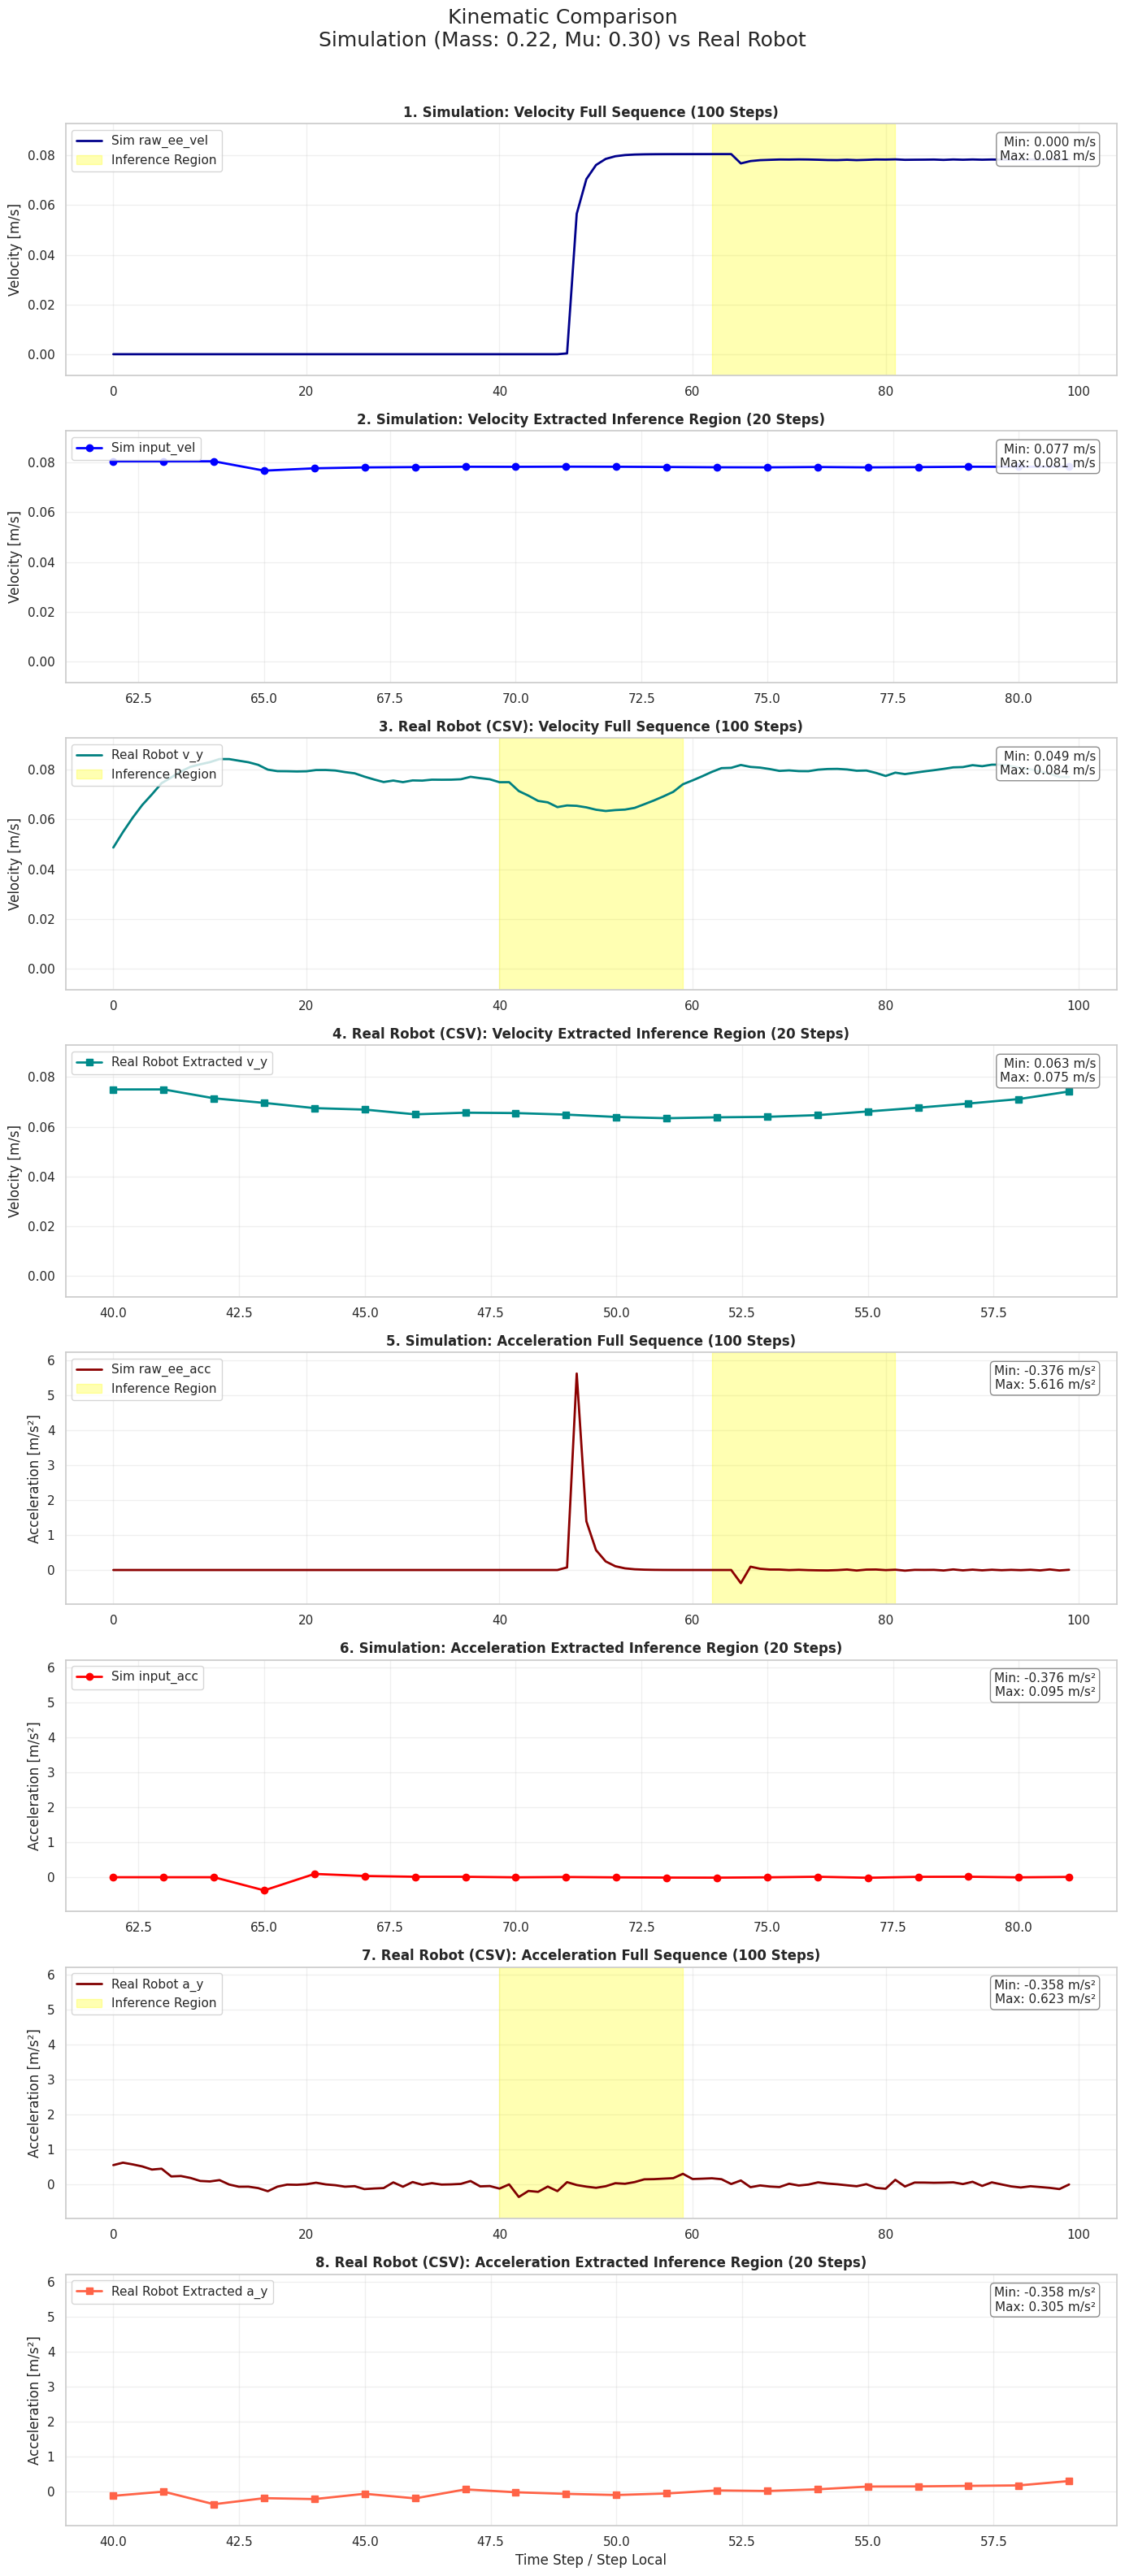

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =================================================================
# CONFIGURATION: Target Physics & Data Paths
# =================================================================
target_mass = 0.2159      # Target GT Mass (kg)
target_mu = 0.3         # Target GT Friction
AXIS_MOTION = 3         # Assuming axis 3 is your motion axis
csv_path = "/home/psxkf4/panda_phypush/csv_data/infe_mest_0.216_muest_0.491_w5.csv"

# =================================================================
# 1. FIND CLOSEST SIMULATION SAMPLE
# =================================================================
if 'df' in locals():
    # Calculate Euclidean distance to the target properties
    df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    
    # Get the single closest sample
    closest_idx = df['dist'].idxmin()
    row = df.loc[closest_idx]
    
    m_val = row['gt_mass']
    mu_val = row['gt_mu']
    print(f"\n✅ Selected Simulation Sample #{closest_idx}")
    print(f"   Target: Mass {target_mass:.3f}, Mu {target_mu:.3f}")
    # print(f"   Actual: Mass {m_val:.3f}, Mu {mu_val:.3f} (Domain: {row['domain']})")

    # Extract Simulation Data
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)
    
    # Clean up
    df.drop(columns=['dist'], inplace=True)
else:
    print("❌ Error: 'df' not found. Please run the data loading cell first.")
    raise ValueError("Missing Simulation DataFrame.")

# =================================================================
# 2. LOAD CSV DATA (Real Robot)
# =================================================================
if os.path.exists(csv_path):
    data_test = pd.read_csv(csv_path)
    steps_csv = data_test['step_local'].values
    v_csv = data_test['v_y'].values
    a_csv = data_test['a_y'].values
    is_inf = data_test['is_inference_region'].values
    
    inf_indices = np.where(is_inf == 1)[0]
    if len(inf_indices) > 0:
        steps_ext = steps_csv[inf_indices]
        v_ext = v_csv[inf_indices]
        a_ext = a_csv[inf_indices]
    else:
        steps_ext, v_ext, a_ext = [], [], []
else:
    print(f"❌ File not found: {csv_path}")
    data_test = None
    v_csv, a_csv = [0], [0]

# =================================================================
# 3. CALCULATE SHARED SCALES (GLOBAL LIMITS)
# =================================================================
sim_v_full = raw_vel[:, AXIS_MOTION]
sim_a_full = raw_acc[:, AXIS_MOTION]

v_min = min(np.min(sim_v_full), np.min(v_csv))
v_max = max(np.max(sim_v_full), np.max(v_csv))
v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
shared_v_lim = (v_min - v_pad, v_max + v_pad)

a_min = min(np.min(sim_a_full), np.min(a_csv))
a_max = max(np.max(sim_a_full), np.max(a_csv))
a_pad = (a_max - a_min) * 0.1 if (a_max - a_min) > 0 else 0.01
shared_a_lim = (a_min - a_pad, a_max + a_pad)

# Helper for stats
def add_min_max_text(ax, data, unit=""):
    if len(data) == 0: return
    dmin, dmax = np.min(data), np.max(data)
    stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# =================================================================
# 4. UNIFIED VISUALIZATION (8 Subplots)
# =================================================================
fig, axes = plt.subplots(8, 1, figsize=(14, 32))
fig.suptitle(f"Kinematic Comparison\nSimulation (Mass: {m_val:.2f}, Mu: {mu_val:.2f}) vs Real Robot", fontsize=18, y=0.99)

# ----------------- VELOCITY -----------------
# 1. SIMULATION: Velocity (100 Steps)
axes[0].plot(np.arange(len(raw_vel)), sim_v_full, color='darkblue', linewidth=2, label='Sim raw_ee_vel')
axes[0].set_title("1. Simulation: Velocity Full Sequence (100 Steps)", fontweight='bold')
axes[0].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[0], sim_v_full, "m/s")
axes[0].axvspan(time_steps[0], time_steps[-1], color='yellow', alpha=0.3, label='Inference Region')
axes[0].set_ylim(shared_v_lim)
axes[0].legend(loc='upper left')

# 2. SIMULATION: Velocity (20 Steps)
axes[1].plot(time_steps, input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel')
axes[1].set_title("2. Simulation: Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
axes[1].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[1], input_vel, "m/s")
axes[1].set_ylim(shared_v_lim)
axes[1].legend(loc='upper left')

if data_test is not None:
    # 3. REAL ROBOT: Velocity (100 Steps)
    axes[2].plot(steps_csv, v_csv, color='teal', linewidth=2, label='Real Robot v_y')
    axes[2].set_title("3. Real Robot (CSV): Velocity Full Sequence (100 Steps)", fontweight='bold')
    axes[2].set_ylabel("Velocity [m/s]")
    add_min_max_text(axes[2], v_csv, "m/s")
    if len(inf_indices) > 0:
        axes[2].axvspan(steps_csv[inf_indices[0]], steps_csv[inf_indices[-1]], color='yellow', alpha=0.3, label='Inference Region')
    axes[2].set_ylim(shared_v_lim)
    axes[2].legend(loc='upper left')

    # 4. REAL ROBOT: Velocity (20 Steps)
    if len(inf_indices) > 0:
        axes[3].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
        axes[3].set_title("4. Real Robot (CSV): Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
        axes[3].set_ylabel("Velocity [m/s]")
        add_min_max_text(axes[3], v_ext, "m/s")
        axes[3].set_ylim(shared_v_lim)
        axes[3].legend(loc='upper left')

# ----------------- ACCELERATION -----------------
# 5. SIMULATION: Acceleration (100 Steps)
axes[4].plot(np.arange(len(raw_acc)), sim_a_full, color='darkred', linewidth=2, label='Sim raw_ee_acc')
axes[4].set_title("5. Simulation: Acceleration Full Sequence (100 Steps)", fontweight='bold')
axes[4].set_ylabel("Acceleration [m/s²]")
add_min_max_text(axes[4], sim_a_full, "m/s²")
axes[4].axvspan(time_steps[0], time_steps[-1], color='yellow', alpha=0.3, label='Inference Region')
axes[4].set_ylim(shared_a_lim)
axes[4].legend(loc='upper left')

# 6. SIMULATION: Acceleration (20 Steps)
axes[5].plot(time_steps, input_acc, color='red', marker='o', linewidth=2, label='Sim input_acc')
axes[5].set_title("6. Simulation: Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
axes[5].set_ylabel("Acceleration [m/s²]")
add_min_max_text(axes[5], input_acc, "m/s²")
axes[5].set_ylim(shared_a_lim)
axes[5].legend(loc='upper left')

if data_test is not None:
    # 7. REAL ROBOT: Acceleration (100 Steps)
    axes[6].plot(steps_csv, a_csv, color='maroon', linewidth=2, label='Real Robot a_y')
    axes[6].set_title("7. Real Robot (CSV): Acceleration Full Sequence (100 Steps)", fontweight='bold')
    axes[6].set_ylabel("Acceleration [m/s²]")
    add_min_max_text(axes[6], a_csv, "m/s²")
    if len(inf_indices) > 0:
        axes[6].axvspan(steps_csv[inf_indices[0]], steps_csv[inf_indices[-1]], color='yellow', alpha=0.3, label='Inference Region')
    axes[6].set_ylim(shared_a_lim)
    axes[6].legend(loc='upper left')

    # 8. REAL ROBOT: Acceleration (20 Steps)
    if len(inf_indices) > 0:
        axes[7].plot(steps_ext, a_ext, color='tomato', marker='s', linewidth=2, label='Real Robot Extracted a_y')
        axes[7].set_title("8. Real Robot (CSV): Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
        axes[7].set_ylabel("Acceleration [m/s²]")
        axes[7].set_xlabel("Time Step / Step Local")
        add_min_max_text(axes[7], a_ext, "m/s²")
        axes[7].set_ylim(shared_a_lim)
        axes[7].legend(loc='upper left')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit the suptitle
plt.show()